**Weather Forecasting with sktime**<br>

Weather forecasting is widely recognized as a notoriously challenging task. This notebook aims to demonstrate the implementation of sktime algorithm (specifically VAR) rather than focusing on creating a highly accurate weather forecast model (although a simple prediction is provided). Some interesting preprocessing steps are applied: a second-degree polynomial detrender, z-score normalization to remove arbitrary units, followed by VAR estimation. Extensive post-estimation testing reveals that the residuals are not normally distributed and exhibit heteroscedasticity.

<br>**What is VAR?**<br>

VAR (Vector Autoregression) is a classic multivariate linear model that has been extensively researched for decades. The model assumes that each variable depends linearly on its own lagged values and the lagged values of all other variables in the system. It is widely used in econometrics and time series analysis. However, its effectiveness depends on whether its underlying assumptions are met, such as stationarity of the time series and absence of serial correlation in the residuals. When these assumptions hold true, VAR can be a very powerful tool for modeling and forecasting multivariate time series data.

<br>**What is sktime?**<br>

Sktime is an open-source Python library specifically designed for time series analysis and forecasting tasks. It provides a user-friendly interface similar to sklearn (scikit-learn) and integrates seamlessly with it. sktime is particularly useful for applying sklearn machine learning algorithms to time series forecasting tasks, including gridsearching them.

In [1]:
import time

# data manipulation
import numpy as np
import pandas as pd

# plots creation
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
%matplotlib inline

# preprocessing
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.trend import PolynomialTrendForecaster
from sklearn.preprocessing import StandardScaler

# statistical interference
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera

# pipelining 
from sktime.forecasting.compose import TransformedTargetForecaster

# sktime adaptor for sklearn scalers
from sktime.transformations.series.adapt import TabularToSeriesAdaptor

# VAR model
from sktime.forecasting.var import VAR

# 1) Overview

In [2]:
ts = pd.read_csv('/home/petewojtczak/datasets_csv/Weather Data.csv')
ts.head(3)

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"


In [3]:
ts.rename(columns={'Date/Time': 'date_time'}, inplace=True)
ts.date_time.dtypes, ts.shape, ts.isnull().values.any(), ts.duplicated().sum()

(dtype('O'), (8784, 8), False, 0)

In [4]:
ts['date_time'] = pd.to_datetime(ts['date_time'])
ts.set_index('date_time', inplace=True)

feature_info = {
    'feature': [],
    'dtype': [],
    'unique_val': [],
    }

for col in ts.columns:
    feature_info['feature'].append(col)
    feature_info['dtype'].append(ts[col].dtype)
    feature_info['unique_val'].append(len(ts[col].unique()))

# features' metadata dataframe
features = pd.DataFrame(feature_info)
features.set_index('feature', inplace=True)
features = features.sort_values(by='unique_val', ascending=False)
features

,dtype,unique_val
feature,,
Temp_C,float64,533
Press_kPa,float64,518
Dew Point Temp_C,float64,489
Rel Hum_%,int64,83
Weather,object,50
Wind Speed_km/h,int64,34
Visibility_km,float64,24


In [5]:
# we will just no go into this feature
ts.drop(columns=['Weather'], inplace=True)
# only inherently continous variables are now left
ts.tail(3)

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
date_time,,,,,,
2012-12-31 21:00:00,-0.5,-1.5,93,28,4.8,99.95
2012-12-31 22:00:00,-0.2,-1.8,89,28,9.7,99.91
2012-12-31 23:00:00,0.0,-2.1,86,30,11.3,99.89


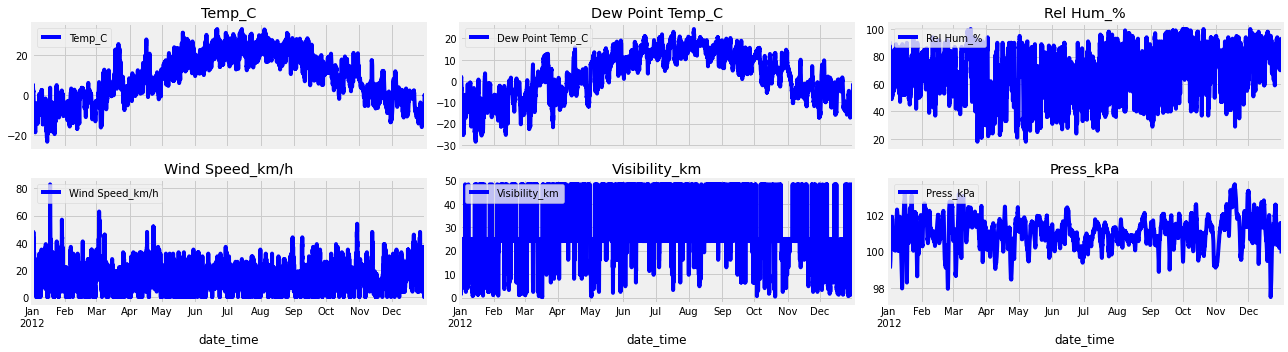

In [6]:
# lets have a look at our time series data
fig, axes = plt.subplots(2, 3, figsize=(18, 5), sharex=True)
for i, col in enumerate(ts.columns):
    ax = axes[i // 3, i % 3]  
    ts[col].plot(ax=ax, color='blue', title=col)
    ax.legend([col], loc=2) 
plt.tight_layout()
plt.show()

# 2) Preprocessing

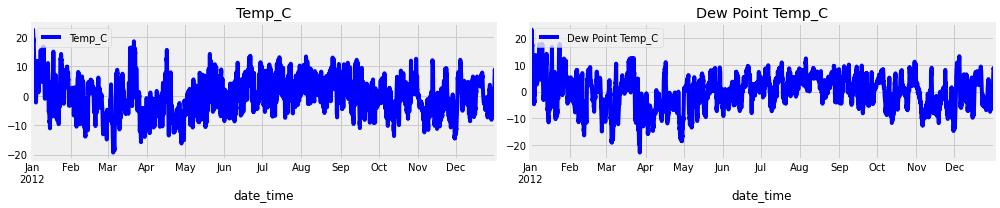

In [7]:
# I think it is a perfect opportunity to apply 2nd degree polynomial detrender
detrender = Detrender(forecaster=PolynomialTrendForecaster(degree=2))
detrended_var = detrender.fit_transform(ts[['Temp_C','Dew Point Temp_C']])

# Create a figure of transformed variables
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for i, col in enumerate(detrended_var.columns):
    detrended_var[col].plot(ax=axes[i], color='blue')
    axes[i].set_title(col)
    axes[i].legend([col], loc=2)
plt.tight_layout()
plt.show()

In [8]:
# let's be honest - these units are purely arbitrary
scaled_ts = pd.concat([detrended_var, ts.drop(columns=['Temp_C','Dew Point Temp_C'], axis=1)], axis=1)
scaler = StandardScaler()
scaled_ts = pd.DataFrame(scaler.fit_transform(scaled_ts), columns=ts.columns)
# preprocessed time-series
scaled_ts

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
0,2.709531,2.845277,1.097553,-1.259808,-1.557954,0.223206
1,2.706776,2.875127,1.156662,-1.259808,-1.557954,0.223206
2,2.704023,2.921022,1.274879,-0.914513,-1.874862,0.246904
3,2.752926,2.950873,1.215770,-1.029611,-1.874862,0.258753
4,2.750173,2.932587,1.215770,-0.914513,-1.811480,0.211358
...,...,...,...,...,...,...
8779,1.518886,1.231915,0.802008,1.732756,-1.423268,-1.092027
8780,1.538514,1.281882,0.920226,1.042164,-1.423268,-1.210516
8781,1.420392,1.428124,1.511315,1.502558,-1.811480,-1.305308
8782,1.474459,1.381819,1.274879,1.502558,-1.423268,-1.352704


# 3) Stationarity and Granger's causality

In [9]:
# stationarity check
for col in scaled_ts.columns:
    result = adfuller(scaled_ts[col], autolag='AIC')
    p_value = result[1]
    is_stationary = 'is stationary' if p_value < 0.05 else 'is not stationary'
    print(f'Variable: {col} {is_stationary}')

Variable: Temp_C is stationary
Variable: Dew Point Temp_C is stationary
Variable: Rel Hum_% is stationary
Variable: Wind Speed_km/h is stationary
Variable: Visibility_km is stationary
Variable: Press_kPa is stationary


In [10]:
def granger_causality_matrix(data, max_lag=3):
    variables = data.columns
    n = len(variables)
    matrix = np.zeros((n, n))
    
    for i, var in enumerate(variables):
        for j, target in enumerate(variables):
            if var != target:
                test_result = grangercausalitytests(data[[target, var]], max_lag, verbose=False)
                min_p_value = np.min([test_result[k+1][0]['ssr_ftest'][1] for k in range(max_lag)])
                matrix[i, j] = min_p_value
    
    return matrix

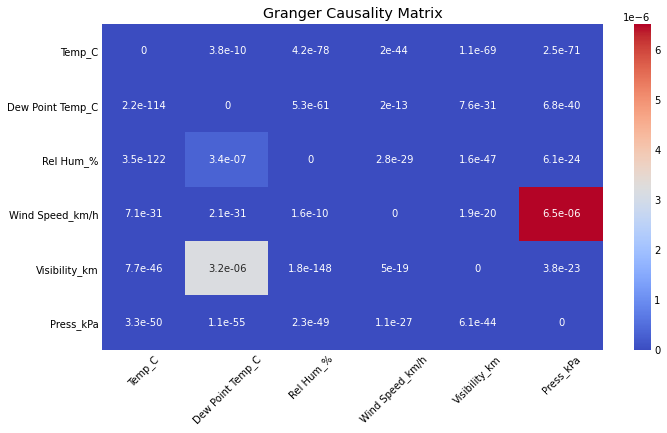

CPU times: user 29 s, sys: 43.1 s, total: 1min 12s
Wall time: 14 s


In [11]:
%%time
# Perform Granger causality test and build the matrix
max_lag = 24
causality_matrix = granger_causality_matrix(scaled_ts, max_lag=max_lag)
# Plotting the causality matrix as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(causality_matrix, annot=True, xticklabels=scaled_ts.columns, yticklabels=scaled_ts.columns, cmap='coolwarm')
plt.title('Granger Causality Matrix')
plt.xticks(rotation=45)
plt.show()

# 4) Estimation and diagnostics

In [12]:
%%time
# our pipeline
fcst_pipeline = TransformedTargetForecaster(
    steps=[
        ('detrender', Detrender(forecaster=PolynomialTrendForecaster(degree=2)), ['Temp_C', 'Dew Point Temp_C']),
        ('z-score', TabularToSeriesAdaptor(StandardScaler()), ts.columns),
        ("forecaster", VAR(maxlags=50, ic='aic'))
    ]
)
fcst_pipeline.fit(ts)

CPU times: user 9.45 s, sys: 9.51 s, total: 19 s
Wall time: 3.6 s


TransformedTargetForecaster(steps=[('detrender',
                                    Detrender(forecaster=PolynomialTrendForecaster(degree=2)),
                                    ['Temp_C', 'Dew Point Temp_C']),
                                   ('z-score',
                                    TabularToSeriesAdaptor(transformer=StandardScaler()),
                                    Index(['Temp_C', 'Dew Point Temp_C', 'Rel Hum_%', 'Wind Speed_km/h',
       'Visibility_km', 'Press_kPa'],
      dtype='object')),
                                   ('forecaster', VAR(ic='aic', maxlags=50))])

In [13]:
residuals = fcst_pipeline.predict_residuals(y=ts)
# this parameter, known as VAR order, is inferred automatically.
print('VAR maxlag parameter: {}'.format(residuals.isnull().values.sum()/len(ts.columns)))
residuals.dropna(inplace=True)

VAR maxlag parameter: 28.0


**Serial correlation testing: Durbin-Watson and Ljung-Box tests.**

In [14]:
alpha = 0.05 
dw_results = {col: durbin_watson(residuals[col]) for col in residuals.columns}
print("Durbin-Watson Test Results:")
for col, dw_stat in dw_results.items():
    if dw_stat < 1.5 or dw_stat > 2.5:
        print(f"   Serial correlation is present in {col} || dw_stat: {round(dw_stat, 3)}")
    else:
        print(f"   No serial correlation in {col} || dw_stat: {round(dw_stat, 3)}")

print("\nLjung-Box Test Results:")
ljung_box_results = {}
for col in residuals.columns:
    ljung_box_results[col] = acorr_ljungbox(residuals[col], lags=[10], return_df=True)
    p_values = ljung_box_results[col]['lb_pvalue']
    if any(p < alpha for p in p_values):
        print(f"   Serial correlation is present in {col}")
    else:
        print(f"   No serial correlation in {col}")

Durbin-Watson Test Results:
   No serial correlation in Temp_C || dw_stat: 1.999
   No serial correlation in Dew Point Temp_C || dw_stat: 1.999
   No serial correlation in Rel Hum_% || dw_stat: 2.0
   No serial correlation in Wind Speed_km/h || dw_stat: 2.0
   No serial correlation in Visibility_km || dw_stat: 2.001
   No serial correlation in Press_kPa || dw_stat: 2.006

Ljung-Box Test Results:
   No serial correlation in Temp_C
   No serial correlation in Dew Point Temp_C
   No serial correlation in Rel Hum_%
   No serial correlation in Wind Speed_km/h
   No serial correlation in Visibility_km
   No serial correlation in Press_kPa


**Jarque-Bera normality test.**

In [15]:
print("Jarque-Bera Test Results:")
for col in residuals.columns:
    jb_stat, jb_p_value = jarque_bera(residuals[col])
    if jb_p_value < alpha:
        print(f"    Residuals are not normally distributed for {col} || test Statistic: {jb_stat} || p-value: {jb_p_value}")
    else:
        print(f"    Residuals are normally distributed for {col} ||test Statistic: {jb_stat} || p-value: {jb_p_value}")

Jarque-Bera Test Results:
    Residuals are not normally distributed for Temp_C || test Statistic: 20438.018787666984 || p-value: 0.0
    Residuals are not normally distributed for Dew Point Temp_C || test Statistic: 9952.461376472194 || p-value: 0.0
    Residuals are not normally distributed for Rel Hum_% || test Statistic: 10756.637571700583 || p-value: 0.0
    Residuals are not normally distributed for Wind Speed_km/h || test Statistic: 20799.539584871716 || p-value: 0.0
    Residuals are not normally distributed for Visibility_km || test Statistic: 13707.923380806671 || p-value: 0.0
    Residuals are not normally distributed for Press_kPa || test Statistic: 11404.578318785778 || p-value: 0.0


**Engle's ARCH Test for residuals heteroscedasticity.**

In [16]:
print("Engle's ARCH Test for Heteroscedasticity:")
for col in residuals.columns:
    test_stat, p_value, _, _ = het_arch(residuals[col])
    if p_value < alpha:
        print(f"    Residuals are heteroscedastic for {col} || test Statistic: {test_stat} || p-value: {p_value}")
    else:
        print(f"    Residuals are homoscedastic for {col} || test Statistic: {test_stat} || p-value: {p_value}")

Engle's ARCH Test for Heteroscedasticity:
    Residuals are heteroscedastic for Temp_C || test Statistic: 204.51879941256772 || p-value: 1.8410332513503228e-38
    Residuals are heteroscedastic for Dew Point Temp_C || test Statistic: 326.19513689553133 || p-value: 4.44550293750497e-64
    Residuals are heteroscedastic for Rel Hum_% || test Statistic: 145.98397220017205 || p-value: 2.4945666013482878e-26
    Residuals are heteroscedastic for Wind Speed_km/h || test Statistic: 49.280459663292184 || p-value: 3.6184232401807894e-07
    Residuals are heteroscedastic for Visibility_km || test Statistic: 98.19829871227483 || p-value: 1.2493544362084547e-16
    Residuals are heteroscedastic for Press_kPa || test Statistic: 852.9398912380334 || p-value: 8.509054918362357e-177


The model diagnostics reveal that residuals are heteroscedastic and not normally distributed. Possible actions to mitigate these problems may include:
* Re-evaluating the Model Specification (lag order, additional endogenous or exogenous variables)
* Further transformation of Variables (log Transformation, Box-Cox transformation, differencing)
* Model extensions like GARCH (Generalized Autoregressive Conditional Heteroscedasticity) to explicitly model the changing variance over time.
* Non-linear Models (if non-linear relationships are suspected in data that a linear VAR model cannot capture)

Using a VAR model with heteroscedastic and not normally distributed residuals can complicate the analysis. The validity of standard statistical tests (e.g., t-tests and F-tests) and confidence intervals derived from the model will be affected and cannot be relied on. 

In [17]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
# example forecast generation
fcst = fcst_pipeline.predict(fh=[1,2,3])
fcst

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
date_time,,,,,,
2013-01-01 00:00:00,-0.09,-1.98,86.46,29.05,12.40,99.86
2013-01-01 01:00:00,-0.38,-2.01,87.50,28.58,10.36,99.84
2013-01-01 02:00:00,-0.64,-2.08,87.82,27.41,9.27,99.81
